In [1]:
import pandas as pd
import  numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

In [2]:
from sklearn.datasets import make_classification

def analyzer(max_depth):
    # Load the Dataset
    df = pd.read_csv("Social_Network_Ads.csv")

    # Splitting the data into parts of input and output
    X = df.iloc[:, 2:4].values
    y = df.iloc[:, -1].values
    # Train the Decision Tree Classifier
    clf = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    clf.fit(X, y)

    # Create a mesh grid for plotting the decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    # Increased step size from 0.02 to 0.2 to reduce RAM usage for the mesh grid.
    # This will make the plot resolution coarser but use less memory.
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2),
                         np.arange(y_min, y_max, 0.2))

    # Predict classifications on the mesh grid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the contour and the training points
    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors='k')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(f'Decision Tree Classifier (max_depth={max_depth}) Decision Boundary')
    plt.show()

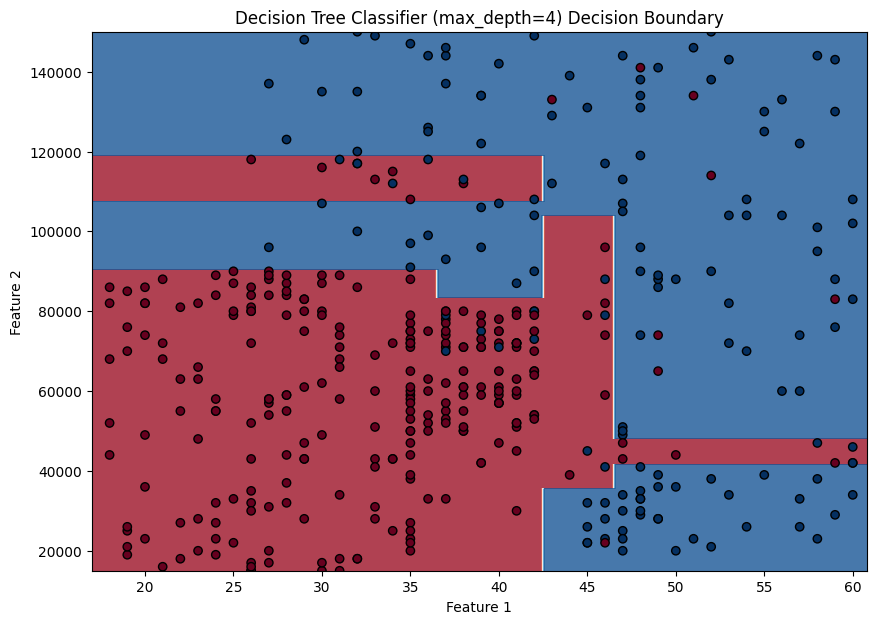

In [3]:
analyzer(max_depth=4)